# Joint Diffusion training

In [1]:
import os
import sys
from pathlib import Path
import time
import json
#import diffusers
sys.path.append(os.path.abspath("diffusionsim"))
import diffusionsim.training_utils as tru
import torch
import torch.nn as nn
from dataclasses import dataclass, asdict, field
from diffusionsim.trainers import *
import pprint

In [2]:
os.environ['XLA_FLAGS'] = '--xla_gpu_cuda_data_dir=/srv/conda/envs/notebook'
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

### Define Configs

In [3]:
from pprint import pprint
REF_BATCH_SIZE = 128
exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
#exp_dir = "/home/jovyan/Samarth/ClimsimProjectWork/diffusion-climsim/experiments"
in_notebook = True

In [4]:

def setup_climsim_run(num_models, exp_id, base_run_id, data_vars='v1', batch_size=128):
    dataset_type = "climsim"
    dconfig = tru.my_dconfig("local-vzarr", data_vars, in_notebook, dataset_type, batch_size, use_tendencies=False)
    dconfig.train_test_split = [0.20, 0.15]
    dconfig.shuffle_indices = False
    tconfigs, mconfigs = [], []

    learning_rates = [1e-4, 1e-4, 1e-4, 1e-4]
    mse_weights = [1.0, 1.0, 1.0, 1.0]
    distloss_weights = [0.0, 0.0, 0.01, 0.01] # [1.0, 1.0, 2.0, 5.0]
    diffloss_weights = [0.0, 10.0, 0.0, 10.0]
    target_variables_distloss = [68, 60, 73, 82]
    num_gaussians = [3, 2, 3, 2]

    lettering = 'abcdefghijklmnopqrstuvwxyz'
    for i in range(num_models):
        tconfig = tru.TrainingConfig(exp_id=exp_id, run_id=f"{base_run_id}{lettering[i]}")
        tconfig.phases = ['train', 'eval']
        tconfig.learning_rate = learning_rates[i] * batch_size / REF_BATCH_SIZE
        tconfig.loss_weights = {'mse': mse_weights[i], 'distribution': distloss_weights[i], 'diffusion': diffloss_weights[i]}
        tconfig.clip_gradients = True
        
        tconfig.distloss_var_inds = target_variables_distloss
        tconfig.num_gaussians = num_gaussians
        tconfig.diffusion_loss_noise_level = 20
        tconfig.distloss_var_sel = "uniform"

        tconfig.log_gradients = True
        tconfig.batch_checkpoint_interval = 50
        tconfigs.append(tconfig)
        
        mconfig = tru.ModelConfig(unet=tru.UNetParams(), scheduler=tru.SchedulerParams())
        mconfig.data_vars = data_vars
        if("climsim" in dataset_type):
            mconfig.model_type = "baseline"
        # define baseline model
        mconfig.bl_hidden_dims = [256, 256, 256] if data_vars == "v1" else [512, 256, 256]
        mconfig.bl_input_size = 124 if data_vars == "v1" else 557
        mconfig.bl_output_size = 128 if data_vars == "v1" else 368
        mconfigs.append(mconfig)

    return(tconfigs, mconfigs, dconfig)




In [5]:
def setup_diffusion_run(num_models, exp_id, base_run_id, data_vars='v1', batch_size=128):
    dataset_type = "xbatch"
    dconfig = tru.my_dconfig("local-vzarr", data_vars, in_notebook, dataset_type, batch_size, use_tendencies=False)
    dconfig.train_test_split = [1.0]
    tconfigs, mconfigs = [], []

    learning_rates = [5e-5, 5e-5, 5e-5, 5e-5]

    lettering = 'abcdefghijklmnopqrstuvwxyz'
    for i in range(num_models):
        tconfig = tru.TrainingConfig(exp_id=exp_id, run_id=f"{base_run_id}{lettering[i]}")
        tconfig.phases = ['train']
        tconfig.learning_rate = learning_rates[i] * batch_size / REF_BATCH_SIZE
        tconfig.lr_scheduler = None
        tconfig.lr_warmup_steps = 500
        tconfig.max_T_sample = 51
        tconfig.clip_gradients = True

        unet = tru.UNetParams()
        unet.block_out_channels = (128, 256, 512) if data_vars == "v1" else (256, 512, 1024)
        unet.down_block_types = ("DownBlock2D", "DownBlock2D", "DownBlock2D")
        unet.up_block_types = ("UpBlock2D", "UpBlock2D", "UpBlock2D")
        unet.in_channels = 128 if data_vars == "v1" else 368
        unet.out_channels = unet.in_channels
        unet.layers_per_block = 1
        unet.norm_num_groups = 2

        scheduler = tru.SchedulerParams()
        scheduler.beta_schedule = "linear"
        scheduler.clip_sample = False
        scheduler.clip_sample_range = 4.0
        scheduler.beta_end = 0.02

        mconfig = tru.ModelConfig(unet=unet, scheduler=scheduler)
        mconfig.model_type = 'ddom_diffusion'
        mconfig.data_vars = data_vars

        tconfigs.append(tconfig)
        mconfigs.append(mconfig)

    return(tconfigs, mconfigs, dconfig)



### Playground for testing scripts

In [5]:
from sklearn.mixture import GaussianMixture
from matplotlib import pyplot as plt
import scipy.stats as stats
import numpy as np

#### Diff training

In [6]:
exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
exp_id = "DiffLossTraining"
run_id = "trial1"

num_models = 4
base_dir = os.path.join(exp_dir, exp_id)

In [4]:
tconfigs, mconfigs, dconfig = setup_run(num_models, exp_id, run_id,
              data_vars='v1', batch_size=128)

dconfig.train_test_split = [0.001]

In [5]:
trainer = DiffusionTrainer(dconfig, mconfigs, tconfigs, torch.nn.MSELoss(), base_dir, rank=0)

ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


In [7]:
trainer.train(num_epochs=1)

Getting ready to train 3 model(s) for 1 epochs
Training for 1 epochs


{"event": "epoch start", "time": 1743658643.1590219, "pid": 1742437, "epoch": 0}
{"event": "batch-0 start", "time": 1743658645.2592452, "pid": 1742437, "batch": 0}
{"event": "run-batch start", "time": 1743658645.259493, "pid": 1742437}
{"event": "run-batch end", "time": 1743658713.6404977, "pid": 1742437, "duration": 68.38098978996277, "trial_1a": 1.1157360076904297, "trial_1b": 1.1225813627243042, "trial_1c": 1.1136373281478882}
{"event": "batch-0 end", "time": 1743658713.6414442, "pid": 1742437, "batch": 0, "duration": 68.38219618797302}


Currently at epoch 0, step 0
Model saved at /mnt/home/ssa2206/Climsim/experiments/diffusion_hp_search/checkpoints/besttrial_1a-ckpt.pt
Model saved at /mnt/home/ssa2206/Climsim/experiments/diffusion_hp_search/checkpoints/besttrial_1b-ckpt.pt
Model saved at /mnt/home/ssa2206/Climsim/experiments/diffusion_hp_search/checkpoints/besttrial_1c-ckpt.pt
Finished training 3 model(s) for 1 epochs.


{"event": "epoch end", "time": 1743658714.4111528, "pid": 1742437, "epoch": 0, "duration": 71.252121925354, "epoch_loss": {"trial_1a": [1.1157360076904297], "trial_1b": [1.1225813627243042], "trial_1c": [1.1136373281478882]}}


In [18]:
print(trainer.dataloaders['train'].dataset.data.sizes)
trainer.dataloaders['train'].dataset.bgen._batch_selectors.selectors


Frozen({'time': 210, 'lev': 60, 'ncol': 384})


{0: [{'time': slice(0, 128, None),
   'lev': slice(0, 60, None),
   'ncol': slice(0, 384, None)}]}

In [5]:
dataloaders, indices = tru.load_dataloaders(dconfig)

ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


In [6]:
dataloader_dict = dict(train=dataloaders[0])
loss_fn = torch.nn.MSELoss()

In [6]:
#mconfig.unet.block_out_channels = (128, 256, 512) #if dconfig.data_vars == "v1" else (256, 512, 1024)
#model = tru.load_model_from_ckpt("trial_1-ckpt.pt", mconfig, exp_id, exp_dir)

In [54]:
bind = ds.bgen._batch_selectors.selectors
bind[5]

[{'time': slice(2560, 3072, None),
  'lev': slice(0, 60, None),
  'ncol': slice(0, 384, None)}]

#### Train Clim

In [8]:
exp_dir = "/home/jovyan/Samarth/ClimsimProjectWork/diffusion-climsim/experiments"
exp_id = "DiffLossTraining"
run_id = "testing_just_mse"

In [6]:
exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
exp_id = "DiffLossTesting"
run_id = "trial2"
num_models = 4
base_dir = os.path.join(exp_dir, exp_id)

In [7]:
tconfigs, mconfigs, dconfig = setup_climsim_run(
    num_models, exp_id, run_id, data_vars='v1', batch_size=64
)

In [25]:
#dconfig.train_test_split = [0.001, 0.001]

pprint(dconfig)
dconfig.train_test_split = [0.001, 0.001]

DataConfig(dataset_type='climsim',
           climsim_type='low-res-expanded',
           source='local-vzarr',
           data_dir='/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests',
           train_test_split=[0.2, 0.15],
           dataloader_params=TrainLoaderParams(batch_size=24576,
                                               shuffle=True,
                                               num_workers=0,
                                               prefetch_factor=None,
                                               persistent_workers=False,
                                               multiprocessing_context=None,
                                               pin_memory=True),
           xarr_subsamples=(36, 210240, 144),
           data_vars='v1',
           use_tendencies=False,
           norm_info='image',
           chunksize={},
           log_batching=True,
           shuffle_indices=False)


In [26]:
trainer = ClimsimTrainer(dconfig, mconfigs, tconfigs, torch.nn.MSELoss(), base_dir, run_id, rank=0)

In [27]:
trainer.indices, len(trainer.dataloaders['train'])


([array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
          13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
          26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
          39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
          52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
          65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
          78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
          91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
         104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
         117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
         130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
         143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
         156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
         169, 170, 171, 172, 173, 174,

In [30]:
trainer.bli = 1
trainer.train(1, log=True)

Getting ready to train 4 model(s) for 1 epochs
Saving configs to /mnt/home/ssa2206/Climsim/experiments/DiffLossTesting/trial2.json
Epoch 1/1
__________


{"event": "epoch-0 start", "time": 1748549804.799313, "pid": 973992}
{"event": "get-item start", "time": 1748549804.7999809, "pid": 973992, "batch_idx": 0}


Currently at epoch 0, step 0/3


{"event": "get-item end", "time": 1748549808.8293967, "pid": 973992, "batch_idx": 0, "duration": 4.029410123825073}
{"event": "run-batch start", "time": 1748549808.8428047, "pid": 973992, "step": 0}


log stepping at 0


{"event": "run-batch end", "time": 1748549811.3839962, "pid": 973992, "duration": 2.5411880016326904, "loss": [4.633231163024902, 5.381290912628174, 5.243656635284424, 6.908066272735596], "step": 0}
{"event": "get-item start", "time": 1748549811.3865929, "pid": 973992, "batch_idx": 2}
{"event": "get-item end", "time": 1748549815.2424629, "pid": 973992, "batch_idx": 2, "duration": 3.855865955352783}
{"event": "run-batch start", "time": 1748549815.2522297, "pid": 973992, "step": 1}


log stepping at 1


{"event": "run-batch end", "time": 1748549818.0895505, "pid": 973992, "duration": 2.8373167514801025, "loss": [4.590574264526367, 5.335712432861328, 5.836515426635742, 6.377585411071777], "step": 1}
{"event": "get-item start", "time": 1748549818.093885, "pid": 973992, "batch_idx": 1}
{"event": "get-item end", "time": 1748549821.7691803, "pid": 973992, "batch_idx": 1, "duration": 3.675291061401367}
{"event": "run-batch start", "time": 1748549821.7789483, "pid": 973992, "step": 2}


log stepping at 2



avg mse loss for epoch 0, run_id trial2a: 4.604272206624349
avg total loss for epoch 0, run_id trial2a: 4.604272206624349
new best! saving new checkpoint at epoch 0
Model saved at /mnt/home/ssa2206/Climsim/experiments/DiffLossTesting/checkpoints/best-trial2a-ckpt.pt
avg diffusion loss for epoch 0, run_id trial2a: 0.07061270127693813
avg distribution loss for epoch 0, run_id trial2a: 32.69928218052223
avg mse loss for epoch 0, run_id trial2b: 4.606588522593181
avg total loss for epoch 0, run_id trial2b: 5.349874496459961
new best! saving new checkpoint at epoch 0
Model saved at /mnt/home/ssa2206/Climsim/experiments/DiffLossTesting/checkpoints/best-trial2b-ckpt.pt
avg diffusion loss for epoch 0, run_id trial2b: 0.07432858645915985
avg distribution loss for epoch 0, run_id trial2b: 1.9653987288572292
avg mse loss for epoch 0, run_id trial2c: 4.620271682739258
avg total loss for epoch 0, run_id trial2c: 5.598298072814941
new best! saving new checkpoint at epoch 0
Model

{"event": "run-batch end", "time": 1748549824.4760468, "pid": 973992, "duration": 2.697093963623047, "loss": [4.589011192321777, 5.332620143890381, 5.714722156524658, 5.352270603179932], "step": 2}
{"event": "epoch-0 end", "time": 1748549824.4807637, "pid": 973992}


In [31]:
trainer.losses #incident  = trainer.nan_incidents['trial1b'][0]

{'trial2a': {'train': {'mse': [4.633231163024902,
    4.590574264526367,
    4.589011192321777],
   'total': [4.633231163024902, 4.590574264526367, 4.589011192321777],
   'diffusion': [0.07061993330717087, 0.0705714151263237, 0.0706467553973198],
   'distribution': [58.94259266535748,
    37.37349747533818,
    1.7817564008710352]}},
 'trial2b': {'train': {'mse': [4.635831356048584,
    4.5928192138671875,
    4.5911149978637695],
   'total': [5.381290912628174, 5.335712432861328, 5.332620143890381],
   'diffusion': [0.0745459496974945, 0.07428930699825287, 0.07415050268173218],
   'distribution': [2.531467244597772,
    1.5187162748012681,
    1.8460126671726471]}},
 'trial2c': {'train': {'mse': [4.641189098358154,
    4.606978893280029,
    4.61264705657959],
   'total': [5.243656635284424, 5.836515426635742, 5.714722156524658],
   'diffusion': [0.07177993655204773,
    0.07177162170410156,
    0.07180877774953842],
   'distribution': [60.24674519713407,
    122.95363672543111,
    1

In [22]:
print(incident.keys())
for name, p in incident['state_dict'].items():
    print(name, p.shape, torch.isnan(p).any())



dict_keys(['step', 'run_id', 'loss_type', 'msg', 'tensor_name', 'tensor_sample', 'state_dict'])
0.weight torch.Size([256, 124]) tensor(False)
0.bias torch.Size([256]) tensor(False)
2.weight torch.Size([256, 256]) tensor(False)
2.bias torch.Size([256]) tensor(False)
4.weight torch.Size([256, 256]) tensor(False)
4.bias torch.Size([256]) tensor(False)
6.weight torch.Size([128, 256]) tensor(False)
6.bias torch.Size([128]) tensor(False)


In [21]:
sample_model = tru.build_baseline_model(mconfigs[0]).to(device)
sample_model.eval()
sample_model.load_state_dict(incident['state_dict'])


<All keys matched successfully>

In [236]:
x, y = trainer.dataloaders['train'].dataset[335]

{"event": "get-item start", "time": 1748493236.7770863, "pid": 837663, "batch_idx": 335}
{"event": "get-item end", "time": 1748493248.063473, "pid": 837663, "batch_idx": 335, "duration": 11.286383152008057}


In [237]:
x, y = x.to(device), y.to(device)
y_hat = sample_model(x)
y_hat.shape, y.shape

(torch.Size([24576, 128]), torch.Size([24576, 128]))

In [239]:
trainer.distribution_loss(y_hat, y, tconfigs[0], 0)

(tensor(10.9021, device='cuda:0', dtype=torch.float64, grad_fn=<DivBackward0>),
 73)

In [93]:
a, b = None, None

In [247]:
step = 0
epsilon=1e-3
tconfig = tconfigs[0]
VAR_IND, num_gaussian = select_distloss_var(tconfig, step)
print(VAR_IND, num_gaussian)
assert isinstance(num_gaussian, int) and isinstance(VAR_IND, int), "num_gaussian and VAR_IND must be integers"
GMM = GaussianMixture(n_components=num_gaussian, reg_covar=epsilon)
GMM.fit(y[:,VAR_IND].detach().cpu().numpy().reshape(-1, 1))
mu = torch.tensor(GMM.means_.flatten(), dtype=torch.float64, device=y_hat.device)[None,:]
pi = torch.tensor(GMM.weights_.flatten(), dtype=torch.float64, device=y_hat.device)[None,:] 
var = torch.tensor(GMM.covariances_.flatten(), dtype=torch.float64, device=y_hat.device)[None,:]
pi = torch.clamp(pi, min=epsilon)
var = torch.clamp(var, min=epsilon)

with torch.no_grad():
    h = 2 * torch.max(var).item()


bs, n_samples = tconfig.distloss_bs, tconfig.num_distloss_samples
batch_num = y_hat.shape[0] // bs
ix, jx = torch.randint(0, batch_num, (n_samples,)), torch.randint(0, batch_num, (n_samples,))
mask = ix == jx
while mask.any():
    ix[mask] = torch.randint(0, batch_num, (mask.sum(),))
    jx[mask] = torch.randint(0, batch_num, (mask.sum(),))
    mask = ix == jx
loss = 0
for i,j in zip(ix, jx):
    y1 = y_hat[i*bs : (i+1)*bs, VAR_IND]
    y2 = y_hat[j*bs : (j+1)*bs, VAR_IND]
    loss += u_q(y1, y2, mu, var, pi, h).mean()
    print(loss)
    if(loss.isnan().any()):
        break

60 2
tensor(False, device='cuda:0') tensor(False, device='cuda:0')
tensor(31835.4251, device='cuda:0', dtype=torch.float64,
       grad_fn=<AddBackward0>)
tensor(False, device='cuda:0') tensor(False, device='cuda:0')
tensor(64356.9469, device='cuda:0', dtype=torch.float64,
       grad_fn=<AddBackward0>)
tensor(False, device='cuda:0') tensor(False, device='cuda:0')
tensor(96022.9895, device='cuda:0', dtype=torch.float64,
       grad_fn=<AddBackward0>)
tensor(False, device='cuda:0') tensor(False, device='cuda:0')
tensor(128118.0478, device='cuda:0', dtype=torch.float64,
       grad_fn=<AddBackward0>)
tensor(False, device='cuda:0') tensor(False, device='cuda:0')
tensor(161335.7233, device='cuda:0', dtype=torch.float64,
       grad_fn=<AddBackward0>)
tensor(False, device='cuda:0') tensor(False, device='cuda:0')
tensor(195320.1538, device='cuda:0', dtype=torch.float64,
       grad_fn=<AddBackward0>)
tensor(False, device='cuda:0') tensor(False, device='cuda:0')
tensor(226631.7490, device='cu

In [227]:
def score_function(x, mu, var, pi, clamp_val=10, epsilon=1e-7):
    mahal = (x[:,None] - mu) ** 2 / (2 * var)
    log_probs = torch.log(pi) - 0.5 * torch.log(var * 2 * torch.pi) - torch.clamp(mahal, max=clamp_val)
    qx = torch.exp(torch.logsumexp(log_probs, dim=1, keepdim=True)) + epsilon
        # Compute weighted derivative terms: pi * N(x|mu, var) * (x - mu) / var
    weighted_terms = torch.exp(log_probs) * torch.clamp((x[:,None] - mu) / var, max=clamp_val, min=-clamp_val)  # (N, K)
    # Sum over components and divide by q(x)
    score = -weighted_terms.sum(dim=1, keepdim=True) / qx    # (N, 1)
    return score.squeeze()

def u_q(x_1, x_2, mu, var, pi, h):
    assert len(x_1.shape) == 1 and len(x_2.shape) == 1, "expected 1d input"
    # x_1 and x_2 are samples from q(x), compared to knowledge distribution p(x) represented by mixture model. Thus, they are of shape (n_samples, d)
    sq1 = score_function(x_1, mu, var, pi)
    sq2 = score_function(x_2, mu, var, pi)

    print(sq1.isnan().any(), sq2.isnan().any())

    # Compute the final result based on bandwidth h
    if h == float('inf'):
        return torch.outer(sq1, sq2)
    
    diffs = x_1.unsqueeze(1) - x_2.unsqueeze(0)
    res = torch.outer(sq1, sq2)
    res += (sq1.reshape(-1,1) * diffs) / h**2
    res -= (sq2.reshape(1, -1) * diffs)/h**2
    res += (h**-2 - h**-4 * diffs ** 2)
    res = res * torch.exp(- (diffs ** 2) / (2 * h ** 2)) # kernel matrix
    return(res)

In [206]:
mu, pi, var

(tensor([[-1.1451, -1.1454]], device='cuda:0', dtype=torch.float64),
 tensor([[0.8392, 0.1608]], device='cuda:0', dtype=torch.float64),
 tensor([[0.0011, 0.0011]], device='cuda:0', dtype=torch.float64))

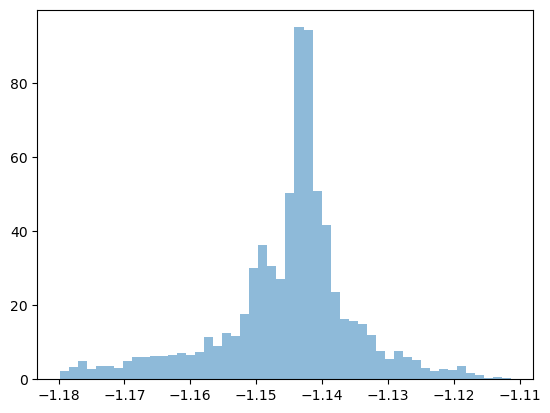

In [204]:
plt.hist(y[:, VAR_IND].detach().cpu().numpy(), bins=50, density=True, alpha=0.5, label='Data')
plt.show()

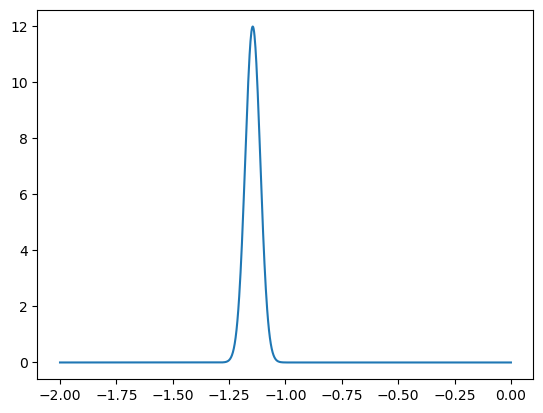

In [205]:
x = torch.linspace(-2, 0, 1000)
density, = eval_density(x, GMM)

plt.plot(x, density)

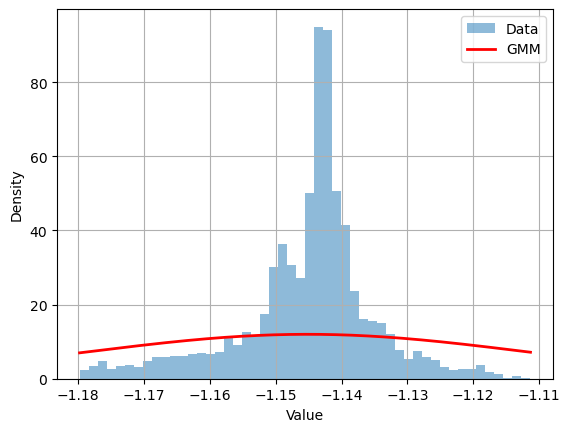

In [202]:
def eval_density(x, GMM=None, training=False, return_components=False):
    if(torch.is_tensor(x)):
        x = x.detach().cpu().reshape(-1, 1)
    elif(len(x.shape) == 1):
        x = x[:, None]
    if(GMM is None):
        GMM = GaussianMixture(n_components=2)
        GMM.fit(x)
    mu = torch.tensor(GMM.means_.flatten(), dtype=torch.float64, device=x.device, requires_grad=training)[None,:] # (n_components,) (nc, d=1 flattened)
    pi = torch.tensor(GMM.weights_.flatten(), dtype=torch.float64, device=x.device, requires_grad=training)[None,:] # (n_components,)
    var = torch.tensor(GMM.covariances_.flatten(), dtype=torch.float64, device=x.device, requires_grad=training)[None,:] 
    log_probs = -0.5 * torch.log(2 * torch.pi * var) - (x - mu)**2 / (2 * var) 
    probs = torch.exp(log_probs)  # (N, K)
    weighted_probs = pi * probs
    q_x = weighted_probs.sum(dim=1, keepdim=True)  # (N, 1)
    if(return_components):
        return(q_x, weighted_probs)
    return(q_x,)

def plot_gmm_distribution(data, gmm, n_points=1000, components=False):
    if(isinstance(data, torch.Tensor)):
        data = data.detach().cpu().numpy()
    # Create a range of x values to evaluate the GMM on
    x = torch.linspace(data.min(), data.max(), n_points)
    ret = eval_density(x, gmm, return_components=components)
    # Plot histogram of actual data
    plt.hist(data, bins=50, density=True, alpha=0.5, label='Data')
    # Plot GMM density
    plt.plot(x, ret[0], 'r-', lw=2, label='GMM')
    if(components):
        plt.plot(x, ret[1][:,0], 'b-', lw=2, label='Component 1')
        plt.plot(x, ret[1][:,1], 'g-', lw=2, label='Component 2')
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    plt.show()
    return(ret[0])

d = plot_gmm_distribution(y[:,VAR_IND].reshape(-1, 1), GMM)

In [135]:
GMM.means_, GMM.covariances_, GMM.weights_

(array([[-1.14240658],
        [-1.1636534 ]]),
 array([[[5.51086799e-05]],
 
        [[8.23181938e-05]]]),
 array([0.87004365, 0.12995635]))

In [16]:
trainer.losses

{'trial1a': {'train': {'mse': [4.659530162811279,
    4.641855239868164,
    4.6658172607421875],
   'total': [4.659530162811279, 4.641855239868164, 4.6658172607421875],
   'diffusion': [0.07212287187576294,
    0.07197009772062302,
    0.07212147861719131],
   'distribution': [1.6887024716882535,
    1.4819232760840662,
    11058.126625712297]},
  'eval': {}},
 'trial1b': {'train': {'mse': [4.636290550231934,
    4.617091655731201,
    4.640247821807861],
   'total': [5.381406784057617, 5.362510681152344, 5.381985664367676],
   'diffusion': [0.07451163977384567,
    0.07454191148281097,
    0.07417380064725876],
   'distribution': [84.47419613673475, 10153.735318689218, 2.332379152242902]},
  'eval': {}},
 'trial1c': {'train': {'mse': [4.604567527770996,
    4.587686061859131,
    4.611870765686035],
   'total': [5.028002738952637, 4.962990760803223, 44.72882843017578],
   'diffusion': [0.07372242212295532,
    0.07365157455205917,
    0.07382892072200775],
   'distribution': [42.3435

In [22]:
means_grads = {}
stds_grads = {}

for k in trainer.gradients['trial1d'].keys():
    means_grads[k] = []
    stds_grads[k] = []
    loss_grads = trainer.gradients['trial1d'][k]
    for name, stats in loss_grads.items():
        if(name == '2.weight'):
            for mean, std in stats:
                means_grads[k].append(mean)
                stds_grads[k].append(std)

In [29]:
means_grads['diffusion']

[2.1443433070089668e-05, 2.0638279238482937e-05, 1.9728104234673083e-05]

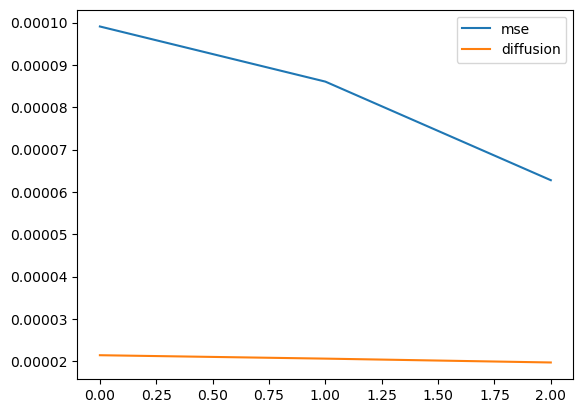

In [30]:
import matplotlib.pyplot as plt
plt.plot(means_grads['mse'], label='mse')
#plt.plot(means_grads['distribution'], label='distribution')
plt.plot(means_grads['diffusion'], label='diffusion')
plt.legend()
plt.show()



In [12]:
x, y = next(iter(trainer.dataloaders['train']))

{"event": "get-batch start", "time": 1748467629.5307288, "pid": 2110854, "batch_idx": 2}
{"event": "get-batch end", "time": 1748467632.978725, "pid": 2110854, "batch_idx": 2, "duration": 3.447993755340576}


In [17]:
trainer.best_losses

{'trial1a': {'mse': inf, 'diffusion': inf, 'distribution': inf},
 'trial1b': {'mse': inf, 'diffusion': inf, 'distribution': inf},
 'trial1c': {'mse': inf, 'diffusion': inf, 'distribution': inf},
 'trial1d': {'mse': inf, 'diffusion': inf, 'distribution': inf}}

In [13]:
batch_losses = trainer._run_batch(x.to(device), y.to(device), 'train', step=0)

{"event": "run-batch start", "time": 1748467662.616888, "pid": 2110854}
{"event": "run-batch end", "time": 1748467662.8276808, "pid": 2110854, "duration": 0.21079063415527344, "loss": 4.592860698699951, "run_id": "trial1a"}
{"event": "run-batch end", "time": 1748467662.9782155, "pid": 2110854, "duration": 0.3613255023956299, "loss": 5.289126396179199, "run_id": "trial1b"}
{"event": "run-batch end", "time": 1748467663.1560235, "pid": 2110854, "duration": 0.5391337871551514, "loss": 4.616513252258301, "run_id": "trial1c"}
{"event": "run-batch end", "time": 1748467663.3137083, "pid": 2110854, "duration": 0.6968183517456055, "loss": 5.320507526397705, "run_id": "trial1d"}


In [23]:
batch_losses

run_id = trainer.run_ids[2]
lw = trainer.training_configs[run_id].loss_weights
l = batch_losses[run_id]
lw, l

({'mse': 1.0, 'distribution': 0.01, 'diffusion': 0.0},
 {'mse': 4.601258277893066,
  'distribution': 1.525495670932516,
  'VAR_IND': 82,
  'diffusion': 0.07281000912189484,
  'total': 4.616513252258301})

In [24]:
total_loss = lw['mse'] * l['mse'] + lw['distribution'] * l['distribution'] + lw['diffusion'] * l['diffusion']

batch_losses[run_id]['total'], total_loss

(4.616513252258301, 4.616513234602391)

In [36]:
from collections import defaultdict
self = trainer
self.distloss_var_counts = {}
for run_id in self.run_ids:
    self.distloss_var_counts[run_id] = defaultdict(int)

In [27]:
trainer.train(num_epochs=1, log=True)

Getting ready to train 4 model(s) for 1 epochs
Saving configs to  /mnt/home/ssa2206/Climsim/experiments/DiffLossTraining/trial1.json
Epoch 1/1
__________


{"event": "epoch-0 start", "time": 1748449308.936858, "pid": 382937}
{"event": "get-batch start", "time": 1748449308.9977887, "pid": 382937, "batch_idx": 2}
{"event": "get-batch end", "time": 1748449313.7843645, "pid": 382937, "batch_idx": 2, "duration": 4.7865684032440186}
{"event": "run-batch start", "time": 1748449313.785193, "pid": 382937}


Currently at epoch 0, step 0/4


InvalidParameterError: The 'n_components' parameter of GaussianMixture must be an int in the range [1, inf). Got [3, 2, 3, 2] instead.

In [62]:
log = trainer.finish_training(log=True, num_epochs=100)

Finished training 100 epochs.


In [12]:
with open(os.path.join(trainer.dirs['log_dir'], 'testing_distloss_a.json'), 'r') as f:
    log_data = json.load(f)

log_data.keys()


dict_keys(['training_config', 'model_config', 'data_config', 'best_loss', 'losses', 'train_loss', 'mse_loss', 'total_loss', 'distribution_loss'])

In [16]:
x, y = trainer.dataloaders['train'].dataset[0]

In [18]:
batch_losses = trainer._run_batch(x.to(device), y.to(device), 'train')

{"event": "run-batch start", "time": 1744078624.836099, "pid": 2475942}
{"event": "run-batch end", "time": 1744078625.155089, "pid": 2475942, "duration": 0.3189873695373535, "loss": 137.5587615966797}
{"event": "run-batch end", "time": 1744078625.459333, "pid": 2475942, "duration": 0.6232316493988037, "loss": 136.02198791503906}
{"event": "run-batch end", "time": 1744078625.790205, "pid": 2475942, "duration": 0.954103946685791, "loss": 149.74610900878906}
{"event": "run-batch end", "time": 1744078626.0908024, "pid": 2475942, "duration": 1.2547011375427246, "loss": 135.84593200683594}


In [38]:
epoch_losses = trainer.log_step(epoch_losses, batch_losses, 32, "train")

In [41]:
batch_losses

{'testing_distloss_a': {'mse': 4.613554000854492,
  'distribution': 132.94520659640085,
  'total': 137.5587615966797},
 'testing_distloss_b': {'mse': 4.6122355461120605,
  'distribution': 131.4097549569163,
  'total': 136.02198791503906},
 'testing_distloss_c': {'mse': 4.62640380859375,
  'distribution': 145.11971086524653,
  'total': 149.74610900878906},
 'testing_distloss_d': {'mse': 4.590487957000732,
  'distribution': 131.25544573709482,
  'total': 135.84593200683594}}

In [42]:
trainer.tracked_losses

['mse',
 'total',
 'distribution',
 'distribution',
 'distribution',
 'distribution']

In [40]:
epoch_losses

defaultdict(dict,
            {'testing_distloss_a': {'mse': [4.613554000854492,
               4.613554000854492,
               4.613554000854492,
               4.613554000854492],
              'total': [137.5587615966797,
               137.5587615966797,
               137.5587615966797,
               137.5587615966797],
              'distribution': [132.94520659640085,
               132.94520659640085,
               132.94520659640085,
               132.94520659640085,
               132.94520659640085,
               132.94520659640085,
               132.94520659640085,
               132.94520659640085,
               132.94520659640085,
               132.94520659640085,
               132.94520659640085,
               132.94520659640085,
               132.94520659640085]},
             'testing_distloss_b': {'mse': [4.6122355461120605,
               4.6122355461120605,
               4.6122355461120605,
               4.6122355461120605],
              'total': [136

In [14]:
trainer.losses

{'testing_distloss_a': {'train': [],
  'mse': [4.620398998260498],
  'total': [141.38180541992188],
  'distribution': [136.76140970271769,
   136.76140970271769,
   136.76140970271769,
   136.76140970271769]},
 'testing_distloss_b': {'train': [],
  'mse': [4.6165971755981445],
  'total': [152.74781799316406],
  'distribution': [148.13122720234637,
   148.13122720234637,
   148.13122720234637,
   148.13122720234637]},
 'testing_distloss_c': {'train': [],
  'mse': [4.647116184234619],
  'total': [142.4958038330078],
  'distribution': [137.84869344469078,
   137.84869344469078,
   137.84869344469078,
   137.84869344469078]},
 'testing_distloss_d': {'train': [],
  'mse': [4.618308067321777],
  'total': [216.10232543945312],
  'distribution': [211.48401037725512,
   211.48401037725512,
   211.48401037725512,
   211.48401037725512]}}

### Validating Data Loading via Buckets (deprecated)

In [8]:
dconfig.dataset_type = "ClimsimImageDataset"
dconfig.source = "gcsfs"
dconfig.train_test_split = [0.05, 0.02]
dconfig.dataloader_params.batch_size = 256
dconfig.dataloader_params

TrainLoaderParams(batch_size=256, shuffle=False, num_workers=0, prefetch_factor=None, persistent_workers=False, multiprocessing_context=None, pin_memory=True)

In [9]:
dsi, dso = cut.load_raw_dataset(dconfig)

In [23]:
datasets, indices = data.train_test_split(dsi, dso, dconfig.train_test_split)
(dsi_train, dso_train), (dsi_test, dso_test) = datasets

In [24]:
from dask.diagnostics import ProgressBar

In [33]:
with ProgressBar():
    dsi_train.load()
    dso_train.load()

[########################################] | 100% Completed | 179.45 s


In [37]:
train_ds = data.ClimsimImageDataset(dsi_train, dso_train, dconfig, log=False)
test_ds =  data.ClimsimImageDataset(dsi_test, dso_test, dconfig, log=False)

## Training no Dist Loss

In [219]:
exp_dir= "/mnt/home/ssa2206/Climsim/experiments"
exp_id = "JointTraining"
run_id = "trial1_just_mse"
base_dir = os.path.join(exp_dir, exp_id)

In [272]:
tconfigs, mconfigs, dconfig = setup_run(4, exp_id, run_id, 'v1', 128)
tconfig = tconfigs[0]
mconfig = mconfigs[0]
dconfig.train_test_split = [0.01, 0.002]
pprint(dconfig)

use_distribution_loss = False
use_diffusion_loss = False

DataConfig(dataset_type='climsim',
           climsim_type='low-res-expanded',
           source='local-vzarr',
           data_dir='/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests',
           train_test_split=[0.01, 0.002],
           dataloader_params=TrainLoaderParams(batch_size=49152,
                                               shuffle=True,
                                               num_workers=0,
                                               prefetch_factor=None,
                                               persistent_workers=False,
                                               multiprocessing_context=None,
                                               pin_memory=True),
           xarr_subsamples=(36, 210240, 144),
           data_vars='v1',
           use_tendencies=False,
           norm_info='image',
           prenormalize=False,
           chunksize={},
           log_batching=True)


In [273]:
dsi, dso, dutils = cut.load_raw_dataset(dconfig, return_dutils=True)


In [12]:
print(dsi.sizes['time'] * dconfig.train_test_split[0], dsi.sizes['time'] * dconfig.train_test_split[1])
#train_indices = np.random.randint(50_000, 100_000, size=2048)
train_dsi, train_dso = dsi.isel(time=slice(0, 2048)), dso.isel(time=slice(0, 2048))

#test_indices = np.random.randint(150_000, 175_000, size=512)
test_dsi, test_dso = dsi.isel(time=slice(2048, 2560)), dso.isel(time=slice(2048, 2560))

train_ds = data.ClimsimDataset(train_dsi.unify_chunks(), train_dso.unify_chunks(), dutils, dconfig, log=True)
test_ds = data.ClimsimDataset(test_dsi.unify_chunks(), test_dso.unify_chunks(), dutils, dconfig, log=True)



2102.38 420.476


In [13]:
item = train_ds[0]

{"event": "get-batch start", "time": 1743144594.0643258, "pid": 161981, "batch_idx": 0}
{"event": "get-batch end", "time": 1743144597.7208855, "pid": 161981, "batch_idx": 0, "duration": 3.656552791595459}


In [14]:
import dataclasses
params = dataclasses.asdict(dconfig.dataloader_params)
params['batch_size'] = 1
dataloaders = [
    torch.utils.data.DataLoader(train_ds, collate_fn=data.collate_test_fn, **params),
    torch.utils.data.DataLoader(test_ds, collate_fn=data.collate_test_fn, **params)
]

In [156]:
mconfig.bl_load_model_name = None
model = tru.build_baseline_model(mconfig).to(device)
loss_fn = torch.nn.MSELoss()
optimizer = tru.create_optimizer(model, tconfig)
rank = 0
model

Sequential(
  (0): Linear(in_features=124, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=256, bias=True)
  (3): ReLU()
  (4): Linear(in_features=256, out_features=256, bias=True)
  (5): ReLU()
  (6): Linear(in_features=256, out_features=128, bias=True)
)

In [157]:
model2 = tru.build_baseline_model(mconfig).to(device)
optimizer2 = tru.create_optimizer(model2, tconfig)

In [24]:
x,y = item
loss_fn(model(x.to(device)), y.to(device))

tensor(4.6360, device='cuda:0', grad_fn=<MseLossBackward0>)

In [35]:
tconfig.loss_weights

{'mse': 1.0, 'distribution': 0.0, 'diffusion': 0.0}

In [36]:
base_dir

'/mnt/home/ssa2206/Climsim/experiments/JointTraining'

In [179]:
def distribution_loss(y_hat, y, tconfig, step, epsilon=1e-7):
    VAR_IND = select_distloss_var(tconfig, step)
    GMM = GaussianMixture(n_components=tconfig.num_gaussians)
    GMM.fit(y[:,VAR_IND].detach().cpu().numpy().reshape(-1, 1))
    mu = torch.tensor(GMM.means_.flatten(), dtype=torch.float64, device=y_hat.device)[None,:]
    pi = torch.tensor(GMM.weights_.flatten(), dtype=torch.float64, device=y_hat.device)[None,:] 
    var = torch.tensor(GMM.covariances_.flatten(), dtype=torch.float64, device=y_hat.device)[None,:]
    pi = torch.clamp(pi, min=epsilon)
    var = torch.clamp(var, min=epsilon)
    
    with torch.no_grad():
        h = 2 * torch.max(var).item()

    bs, n_samples = tconfig.distloss_bs, tconfig.num_distloss_samples
    batch_num = y_hat.shape[0] // bs
    ix, jx = torch.randint(0, batch_num, (n_samples,)), torch.randint(0, batch_num, (n_samples,))
    mask = ix == jx
    while mask.any():
        ix[mask] = torch.randint(0, batch_num, (mask.sum(),))
        jx[mask] = torch.randint(0, batch_num, (mask.sum(),))
        mask = ix == jx
    loss = 0
    for i,j in zip(ix, jx):
        y1 = y_hat[i*bs : (i+1)*bs, VAR_IND]
        y2 = y_hat[j*bs : (j+1)*bs, VAR_IND]
        loss += u_q(y1, y2, mu, var, pi, h).mean()
    return(loss / n_samples, VAR_IND)

In [214]:
loss_fn = torch.nn.MSELoss()
def run_batch(model, x, y, optimizer, loss_weights, loss_dict, use_dist=False):
    x, y = x.to(device), y.to(device)
    y_hat = model(x)
    mse_loss = loss_fn(y_hat, y)
    dist_loss = distribution_loss(y, y_hat)
    if(use_dist):
        total_loss = loss_weights['mse'] * mse_loss + loss_weights['distribution'] * dist_loss
    else:
        total_loss = loss_weights['mse'] * mse_loss
    
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    loss_dict['mse'].append(mse_loss.item())
    loss_dict['distribution'].append(dist_loss.item())
    return(loss_dict)



def train_comparison(m1, m2, optim1, optim2, lw1, lw2, dataloader, num_epochs):
    losses_1 = dict(mse=[], distribution=[])
    losses_2 = dict(mse=[], distribution=[])
    steps_per_epoch = len(dataloader)
    with torch.set_grad_enabled(True):
        for epoch in range(1, num_epochs+1):
            print(f"Currently at epoch {epoch}\n______________________\n")
            for step, (X, Y) in enumerate(dataloader):
                if(step % 16 == 0 and step>0):
                    ms1, d1, ms2, d2 = losses_1['mse'][-1], losses_1['distribution'][-1], losses_2['mse'][-1], losses_2['distribution'][-1]
                    print(f"losses (mse, dist) at step {step}/{steps_per_epoch} | no_dist: ({ms1}, {d1}) | dist: ({ms2}, {d2})")
                losses_1 = run_batch(m1, X, Y, optim1, lw1, losses_1, use_dist=False)
                losses_2 = run_batch(m2, X, Y, optim2, lw2, losses_2, use_dist=True)
            print("finished epoch, saving models")
            torch.save(m1.state_dict(), os.path.join(base_dir, f"trial0_just_mse.pt"))
            torch.save(m2.state_dict(), os.path.join(base_dir, f"trial0_dist_loss.pt"))
    return(losses_1, losses_2)

In [182]:
dataloaders[0].dataset.log  = False

In [236]:
dataloaders[0].dataset.X.sizes['sample'], 786432 / 384 / 72


(786432, 28.444444444444443)

In [212]:
lw1 = {'mse': 1.0, 'distribution': 0.0, 'diffusion': 0.0}
lw2 = {'mse': 1.0, 'distribution': 3e-4, 'diffusion': 0.0}



In [215]:
l1, l2 = train_comparison(model, model2, optimizer, optimizer2, lw1, lw2, dataloaders[0], 4)

Currently at epoch 1
______________________

losses (mse, dist) at step 16/64 | no_dist: (0.5877881050109863, 0.34982294758827215) | dist: (0.5813173055648804, 0.34026044001319916)
losses (mse, dist) at step 32/64 | no_dist: (0.5153149962425232, 0.33619354841283017) | dist: (0.5109403133392334, 0.3326345592375106)
losses (mse, dist) at step 48/64 | no_dist: (0.4670844078063965, 0.3320946102880561) | dist: (0.4660656452178955, 0.32998793228214707)
finished epoch, saving models
Currently at epoch 2
______________________

losses (mse, dist) at step 16/64 | no_dist: (0.4043108820915222, 0.3095711032980733) | dist: (0.39886391162872314, 0.3085147223157662)
losses (mse, dist) at step 32/64 | no_dist: (0.35700997710227966, 0.3047838715680484) | dist: (0.3582896590232849, 0.2994875407762914)
losses (mse, dist) at step 48/64 | no_dist: (0.35542988777160645, 0.3012451573177524) | dist: (0.3556065559387207, 0.3012992903972042)
finished epoch, saving models
Currently at epoch 3
__________________

In [171]:
losses_1, losses_2 = dataloaders[0].dataset.X.sizes['sample'] / 384

2048.0

In [219]:
losses_1['mse'] += l1['mse']
losses_1['distribution'] += l1['distribution']
losses_2['mse'] += l2['mse']
losses_2['distribution'] += l2['distribution']



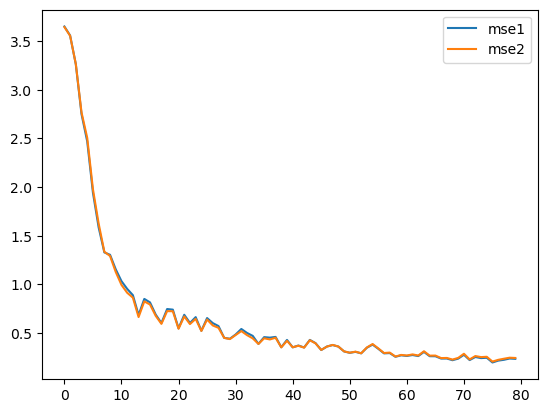

In [221]:
plt.plot(np.array(losses_1['mse'])[::4], label='mse1')
plt.plot(np.array(losses_2['mse'])[::4], label='mse2')
plt.legend()
plt.show()


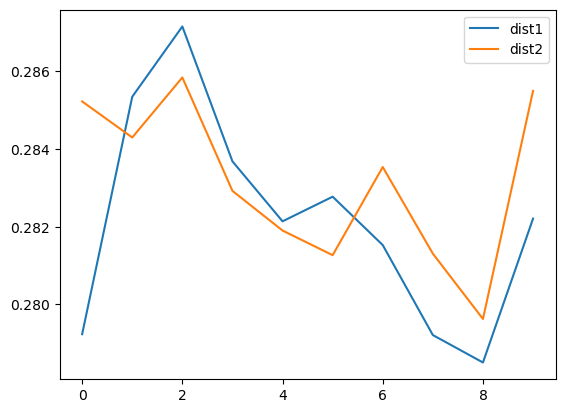

In [223]:
plt.plot(np.array(losses_1['distribution'])[-10:], label='dist1')
plt.plot(np.array(losses_2['distribution'])[-10:], label='dist2')
plt.legend()
plt.show()


In [201]:
import matplotlib.pyplot as plt

In [226]:
log_file = os.path.join(base_dir, "trial0.json")
with open(log_file, "r") as f:
    log_data = json.load(f)




In [229]:
log_data.keys()

dict_keys(['training_config', 'model_config', 'data_config', 'use_distribution_loss', 'use_diffusion_loss', 'mse_only_losses', 'dist_losses'])

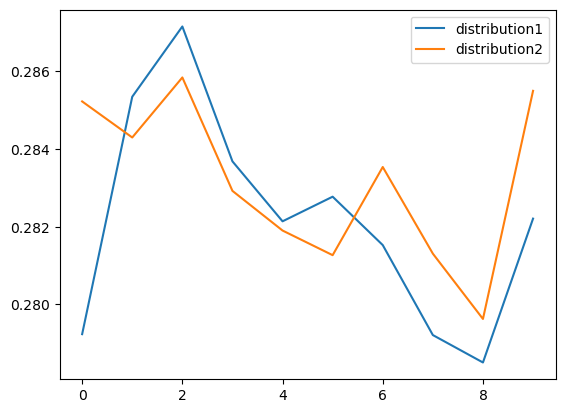

In [231]:
#plt.plot(losses_1['mse'], label='mse1')
plt.plot(log_data['mse_only_losses']['distribution'][-10:], label='distribution1')
#plt.plot(losses_2['mse'], label='mse2')
plt.plot(log_data['dist_losses']['distribution'][-10:], label='distribution2')
plt.legend()
plt.show()

In [98]:
trainer = tru.ClimsimTrainer(model, dataloaders, loss_fn, optimizer, 
                   tconfig, base_dir, use_distribution_loss, use_diffusion_loss, rank=0)

Initializing trainer with rank: 0
Using device: cuda:0


In [108]:
old_stderr = sys.stderr

In [ ]:
with open(os.path.join(trainer.dirs['output_dir'], f"{run_id}.txt"), "w") as f:
    print(f"Redirecting stderr to {f.name}")
    #stderr_fd = sys.stderr.fileno()
    #old_stderr = os.dup(stderr_fd)
    #os.dup2(f.fileno(), stderr_fd)
    sys.stderr = f
    trainer.train(num_epochs=10, log=True, run_id=run_id)


Redirecting stderr to /mnt/home/ssa2206/Climsim/experiments/JointTraining/outputs/trial0_just_mse.txt
Getting ready to train model for 10 epochs
Epoch 1/10
__________
Currently at epoch 0, step 0/64
Currently at epoch 0, step 10/64
Currently at epoch 0, step 20/64
Currently at epoch 0, step 30/64
Currently at epoch 0, step 40/64
epoch 0, step 49: saving checkpoint


# Diffusion Prior Loss

In [8]:
#exp_id = "full_dataset_testrun"
#base_dir = os.path.join("experiments", exp_id)
#run_id = "trial_1b"
#tconfig, mconfig, dconfig = tru.load_config(run_id, exp_id)


In [6]:
exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
exp_id = "DiffLossTraining"
run_id = "trial1"
num_models = 4
base_dir = os.path.join(exp_dir, exp_id)
tconfigs, mconfigs, dconfig = setup_climsim_run(
    num_models, exp_id, run_id, data_vars='v1', batch_size=64
)
dconfig.train_test_split = [0.01, 0.002]


In [7]:
pprint(dconfig)

DataConfig(dataset_type='climsim',
           climsim_type='low-res-expanded',
           source='local-vzarr',
           data_dir='/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests',
           train_test_split=[0.01, 0.002],
           dataloader_params=TrainLoaderParams(batch_size=24576,
                                               shuffle=True,
                                               num_workers=0,
                                               prefetch_factor=None,
                                               persistent_workers=False,
                                               multiprocessing_context=None,
                                               pin_memory=True),
           xarr_subsamples=(36, 210240, 144),
           data_vars='v1',
           use_tendencies=False,
           norm_info='image',
           chunksize={},
           log_batching=True,
           shuffle_indices=False)


In [8]:
unet = tru.load_diffusion_model().to(device)
unet.device

device(type='cuda', index=0)

In [13]:
trainer = ClimsimTrainer(
    dconfig, mconfigs, tconfigs, torch.nn.MSELoss(), base_dir, rank=0,
)

In [11]:
#dtconfigs, dmconfigs, ddconfig = setup_diffusion_run(num_models, exp_id, run_id, data_vars='v1', batch_size=128)
#diff_trainer = DiffusionTrainer(ddconfig, dmconfigs, dtconfigs, torch.nn.MSELoss(), base_dir, rank=0)

In [14]:
trainer.dataloaders['train'], len(trainer.dataloaders['train'])

(<torch.utils.data.dataloader.DataLoader at 0x15523bb92450>, 32)

In [15]:
dl = trainer.dataloaders['train']
ds = dl.dataset

ds.dsi

<xarray.Dataset> Size: 801MB
Dimensions:      (time: 2102, lev: 60, ncol: 384)
Coordinates:
  * time         (time) object 17kB 0001-02-01 00:40:00 ... 0001-03-02 05:00:00
  * ncol         (ncol) int64 3kB 0 1 2 3 4 5 6 ... 377 378 379 380 381 382 383
    lat          (ncol) float64 3kB -32.59 -35.99 -22.69 ... 45.34 45.34 40.39
    lon          (ncol) float64 3kB -39.73 -28.47 -39.56 ... 123.3 146.7 135.0
Dimensions without coordinates: lev
Data variables:
    state_t      (time, lev, ncol) float64 387MB dask.array<chunksize=(251, 8, 96), meta=np.ndarray>
    state_q0001  (time, lev, ncol) float64 387MB dask.array<chunksize=(251, 8, 96), meta=np.ndarray>
    state_ps     (time, ncol) float64 6MB dask.array<chunksize=(251, 96), meta=np.ndarray>
    pbuf_SOLIN   (time, ncol) float64 6MB dask.array<chunksize=(251, 96), meta=np.ndarray>
    pbuf_LHFLX   (time, ncol) float64 6MB dask.array<chunksize=(251, 96), meta=np.ndarray>
    pbuf_SHFLX   (time, ncol) float64 6MB dask.array<chunksize=(251, 96), meta=np.ndarray>

In [16]:
x, y = ds[0]
x, y = x.to(device), y.to(device)

{"event": "get-batch start", "time": 1748466423.5728226, "pid": 2106584, "batch_idx": 0}
{"event": "get-batch end", "time": 1748466426.7770205, "pid": 2106584, "batch_idx": 0, "duration": 3.2041940689086914}


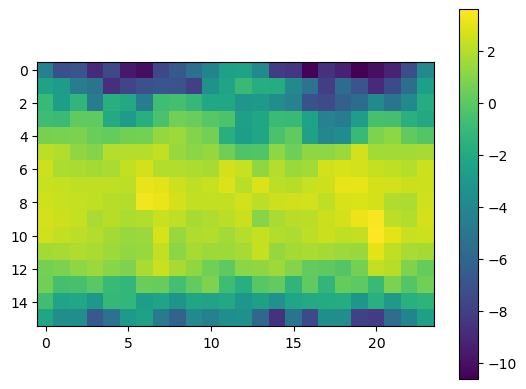

In [19]:
import matplotlib.pyplot as plt
y_img = trainer._make_image(y)
tmap = y_img[5, 59, :, :].detach().cpu().numpy()
plt.imshow(tmap)
plt.colorbar()
plt.show()


In [20]:
"""
dy = diff_trainer.dataloaders['train'].dataset[0]
dyu = dy * ds.ys[None, :, None, None] + ds.ym[None, :, None, None]
dtmap = dyu[5, 59, :, :].detach().cpu().numpy()

plt.imshow(dtmap)
plt.colorbar()
plt.show()
"""
y_hat = clim_trainer.models[clim_trainer.run_ids[0]](x)

In [21]:
y.shape, y_hat.shape

(torch.Size([24576, 128]), torch.Size([24576, 128]))

In [42]:
def diffusion_loss(self, y_hat, run_id):
    #raise NotImplementedError("Diffusion loss not implemented")
    # TODO: y and yhat are of size (B, 128) and somehow need to convert into images for diffusion loss
    tconfig = self.training_configs[run_id]
    scheduler = self.schedulers[run_id]
    y_image = self._make_image(y_hat)
    tconfig.diffusion_loss_noise_level = 10
    print(tconfig.diffusion_loss_noise_level)
    def encode(sample):
        eps = torch.randn(sample.shape, device=sample.device) # BS x C x H x W
        xt = scheduler.add_noise(sample, eps, torch.LongTensor([tconfig.diffusion_loss_noise_level])) # noisy image
        return(xt)
    def decode(xt):
        with torch.no_grad():
            for t in range(tconfig.diffusion_loss_noise_level, 0, -tconfig.diffusion_loss_decoding_interval):
                eps_theta = self.unet(xt, t).sample
                xt = scheduler.step(eps_theta, t, xt).prev_sample
        return(xt)
    y_image_denoised = decode(encode(y_image))
    return(self.loss_fn(y_image_denoised, y_image))

In [44]:
diff_loss = diffusion_loss(trainer, y_hat, trainer.run_ids[0])
diff_loss

10


tensor(0.0305, device='cuda:0', grad_fn=<MseLossBackward0>)

In [40]:
trainer.loss_fn(y_hat, y)

tensor(4.6545, device='cuda:0', grad_fn=<MseLossBackward0>)

In [46]:
tconfig = trainer.training_configs[trainer.run_ids[0]]
trainer.distribution_loss(y_hat, y, tconfig, step=0)

(tensor(4741.1358, device='cuda:0', dtype=torch.float64, grad_fn=<DivBackward0>),
 60)

In [103]:
loss_fn = nn.MSELoss()
def image_loss(y, yhat, T: int, unet=ddpm, scheduler=scheduler):
    y, yhat = construct_image(y), construct_image(yhat)
    def encode(sample):
        eps = torch.randn(sample.shape, device=device) # BS x C x H x W
        xt = scheduler.add_noise(sample, eps, torch.LongTensor([T])) # noisy image
        return(xt)
    def decode(xt):
        for t in range(T, 0, -1):
            with torch.no_grad():
                eps_theta = unet(xt, t).sample
            xt = scheduler.step(eps_theta, t, xt).prev_sample
        return(xt)
    yhat = decode(encode(yhat))
    return(loss_fn(y, yhat))

In [54]:
image_loss(y.to(device), y_hat, 25)

tensor(1.4329, device='cuda:0', grad_fn=<MseLossBackward0>)

In [62]:
4204/256

16.421875

In [69]:
tconfig.num_epochs

20

In [72]:

len(test_ds)

8

In [80]:
%%time
c, d = train_ds[5]

CPU times: user 437 ms, sys: 1.85 ms, total: 438 ms
Wall time: 402 ms


In [81]:
%%time
loss_fn(model(a.to(device)), b.to(device))

CPU times: user 29.9 ms, sys: 0 ns, total: 29.9 ms
Wall time: 29.5 ms


tensor(0.9858, device='cuda:0', grad_fn=<MseLossBackward0>)

In [76]:
def evaluate_diff(model):
    loss = 0.0
    model.eval()
    with torch.no_grad():
        for idx in range(len(test_ds)):
            print(idx, end=" ")
            x, y = test_ds[idx]
            x, y = x.to(device), y.to(device)
            loss += loss_fn(model(x), y).item()
    return(loss / len(test_ds))

In [107]:
scheduler.timesteps

tensor([99, 98, 97, 96, 95, 94, 93, 92, 91, 90, 89, 88, 87, 86, 85, 84, 83, 82,
        81, 80, 79, 78, 77, 76, 75, 74, 73, 72, 71, 70, 69, 68, 67, 66, 65, 64,
        63, 62, 61, 60, 59, 58, 57, 56, 55, 54, 53, 52, 51, 50, 49, 48, 47, 46,
        45, 44, 43, 42, 41, 40, 39, 38, 37, 36, 35, 34, 33, 32, 31, 30, 29, 28,
        27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10,
         9,  8,  7,  6,  5,  4,  3,  2,  1,  0])

In [121]:
def diffusion_train(model, dataset, loss_fn, tconfig):
    optimizer = torch.optim.Adam(model.parameters(), lr=tconfig.learning_rate, weight_decay=1e-4)
    losses = dict(train=[], diffusion=[], test=[])
    for epoch in range(1, tconfig.num_epochs+1):
        model.train()  # Set the model to training mode
        pixel_loss, img_loss = 0.0, 0.0
        for idx in range(len(dataset)):
            print(idx, end=" ")
            x, y = dataset[idx]
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(x)
            ploss = loss_fn(y, y_hat)
            iloss = image_loss(y, y_hat, T=25)
            (ploss + iloss).backward()
            optimizer.step()
            pixel_loss += ploss.item(); img_loss += iloss.item()
            losses['train'].append(ploss.item()); losses['diffusion'].append(iloss.item());
        # Print training progress
        #average_loss = running_loss / len(dataloader)
        #test_loss = evaluate(model).item()
        print(f'\nEpoch [{epoch}/{tconfig.num_epochs}], Pixel Loss: {pixel_loss/len(dataset):.4f}, Image Loss: {img_loss/len(dataset):.4f}')
        
        if(epoch % tconfig.batch_checkpoint_interval == 0):
            print("Saving Model")
            torch.save(model.state_dict(), tconfig.ckpt_id)

    return(model, losses)

In [116]:
model = nn.Sequential(
    nn.Linear(in_features=124, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=128),
).to(device)

In [122]:
loss_fn(model(x.to(device)), y.to(device))

tensor(1.3941, device='cuda:0', grad_fn=<MseLossBackward0>)

In [123]:
x, y = train_ds[0]

In [127]:
model, losses = diffusion_train(model, train_ds, loss_fn, tconfig)

0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [1/10], Pixel Loss: 1.0640, Image Loss: 1.0884
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [2/10], Pixel Loss: 1.0268, Image Loss: 1.0556
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [3/10], Pixel Loss: 0.9956, Image Loss: 1.0274
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [4/10], Pixel Loss: 0.9671, Image Loss: 1.0011
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [5/10], Pixel Loss: 0.9403, Image Loss: 0.9758
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [6/10], Pixel Loss: 0.9146, Image Loss: 0.9515
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [7/10], Pixel Loss: 0.8901, Image Loss: 0.9280
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [8/10], Pixel Loss: 0.8668, Image Loss: 0.9055
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [9/10], Pixel Loss: 0.8446, Image Loss: 0.8840
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [10/10], Pixel Loss: 0.8236, Image Loss: 0.8637


In [130]:
torch.save(model.state_dict(), "experiments/JointTraining/diffusion_train.pt")

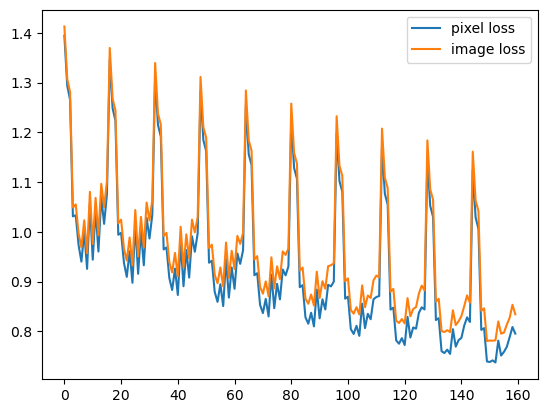

In [134]:
plt.plot(losses['train'], label='pixel loss')
plt.plot(losses['diffusion'], label='image loss')
plt.legend()
plt.show()

In [137]:
import json

In [139]:
with open("experiments/JointTraining/diffusion_train_losses.json", "w") as file:
    json.dump(losses, file)